In [1]:
from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score,r2_score
import pandas as pd


In [2]:
x,y = make_classification(n_samples=1000, random_state=42, n_features=50)
df = pd.concat([pd.DataFrame(x),pd.DataFrame(y,columns= ['label'])],axis = 1)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,41,42,43,44,45,46,47,48,49,label
0,-0.904948,0.256171,1.329173,0.613771,-1.242247,0.475588,0.034030,0.167570,-0.517757,-0.347186,...,-1.998889,-1.632015,0.894911,-2.201243,-0.303626,-1.125587,0.375456,-0.254947,-0.538761,0
1,-2.351224,-0.731497,0.178454,-0.450619,-0.063583,1.161918,-2.384745,-0.775379,-1.112332,0.289715,...,1.942380,-1.118877,1.530094,-1.580156,0.690822,-1.019361,0.106907,1.074559,-0.126986,0
2,-0.476199,0.436768,-0.262416,0.089361,0.571283,-1.816267,0.865359,0.614106,1.283739,-0.584493,...,0.326832,-0.106132,0.091480,0.534469,-0.529778,-1.621453,0.984570,-0.570194,0.735681,1
3,1.532873,2.492184,1.357913,0.954085,0.049328,-0.147340,0.817306,2.202014,2.178562,-1.965556,...,0.820232,0.001977,-0.416438,-1.694973,1.025632,0.722447,1.218480,0.399228,0.249451,0
4,0.801896,0.313267,-1.384471,-0.728882,-1.258612,1.782412,0.654684,1.328972,-1.120988,-0.030876,...,0.973707,-0.357715,-0.232788,-0.685510,0.408337,-1.133970,0.391175,-0.425478,-2.031748,1


In [3]:
x_train,x_test,y_train,y_test  = train_test_split(df.drop('label', axis = 1),df['label'] , test_size=0.2, random_state = 42)


In [4]:
model =  GradientBoostingClassifier()
model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print("Classfication report",classification_report(y_pred,y_test))


Classfication report               precision    recall  f1-score   support

           0       0.92      0.90      0.91        97
           1       0.90      0.92      0.91       103

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200



In [8]:
# GradientBoostingClassifier(loss=['log_loss','deviance','exponential'], n_estimators=[100,150,200,250,300,350], max_depth=[1,2,3,4,5,6,7,8,9], random_state=42,max_features=[None,'auto','sqrt','log2'])


params = {
    'loss': ['log_loss','exponential'],
    'n_estimators':[100,150,200,250,300,350],
    'learning_rate':[0.01,0.01,0.5,0.1,0.15,],
    'max_depth': [1,2,3,4,5],
    'max_features': [None,'sqrt','log2']
}


clf = RandomizedSearchCV(GradientBoostingClassifier(random_state=42), params, n_iter=100, cv = 5, n_jobs=-1 )
clf.fit(x_train,y_train)
print(clf.best_params_)
print(clf.best_score_)

{'n_estimators': 300, 'max_features': None, 'max_depth': 5, 'loss': 'log_loss', 'learning_rate': 0.01}
0.9025000000000001


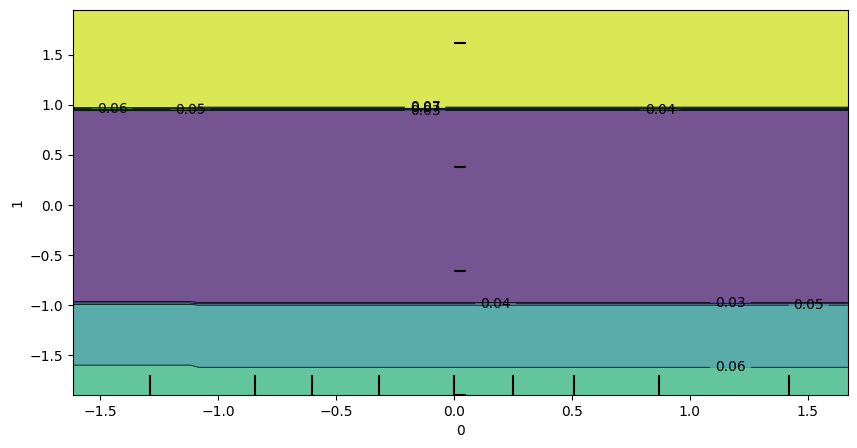

In [10]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

fig, ax = plt.subplots(figsize=(10, 5))
PartialDependenceDisplay.from_estimator(model, x_test, features=[(0, 1)], ax=ax)
plt.show()